In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import torch
from src.data.dataset import GrainDataset, create_dataloaders

%matplotlib inline

## Load Dataset

In [3]:
# Create dataloaders for fold 0
train_loader, val_loader = create_dataloaders(
    fold=0,
    data_dir='../data/processed',
    batch_size=16,
    num_workers=0
)

Loaded 1907 samples for train split
  Class distribution:
    Peloid         : 1679 (88.04%)
    Ooid           :  121 ( 6.35%)
    Broken ooid    :   21 ( 1.10%)
    Intraclast     :   86 ( 4.51%)
Loaded 735 samples for val split
  Class distribution:
    Peloid         :  621 (84.49%)
    Ooid           :   89 (12.11%)
    Broken ooid    :    8 ( 1.09%)
    Intraclast     :   17 ( 2.31%)


## Visualize Training Samples (with augmentation)

c:\Users\mswr\dev\facies\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


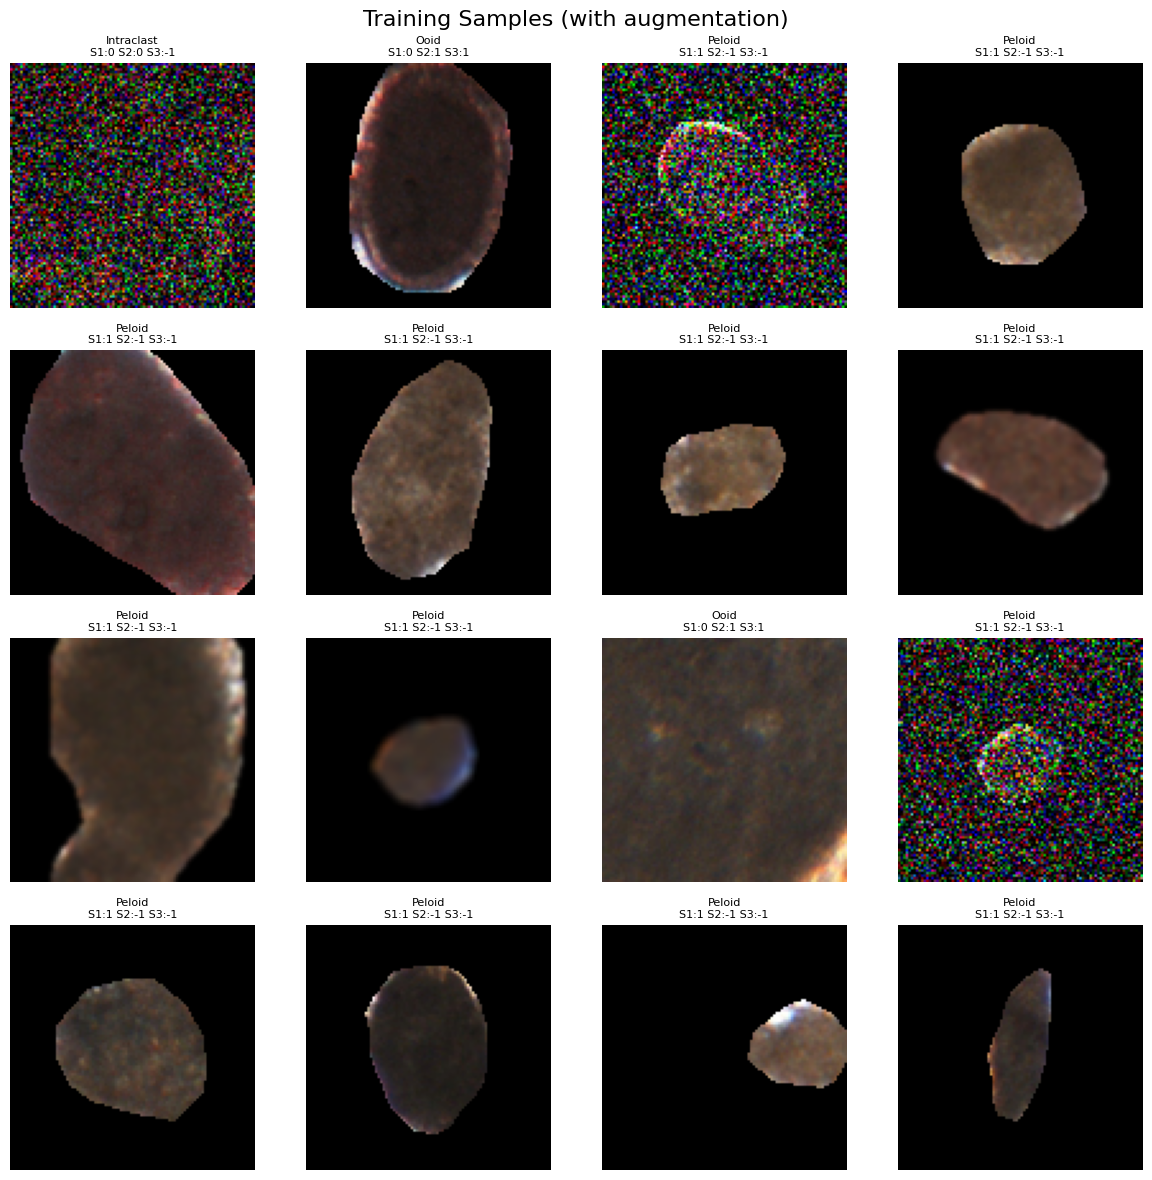

In [4]:
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize ImageNet-normalized tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

def visualize_batch(loader, title, num_samples=16):
    """Visualize a batch of samples."""
    images, labels, metadata = next(iter(loader))
    
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle(title, fontsize=16)
    
    for idx in range(num_samples):
        ax = axes[idx // 4, idx % 4]
        
        # Denormalize and convert to numpy
        img = denormalize(images[idx])
        img = img.permute(1, 2, 0).numpy()
        
        ax.imshow(img)
        ax.axis('off')
        
        # Create label text
        label_text = metadata['label'][idx]
        stage1 = labels['stage1'][idx].item()
        stage2 = labels['stage2'][idx].item()
        stage3 = labels['stage3'][idx].item()
        
        label_info = f"{label_text}\nS1:{stage1} S2:{stage2} S3:{stage3}"
        ax.set_title(label_info, fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Visualize training samples (augmented)
visualize_batch(train_loader, "Training Samples (with augmentation)")

## Visualize Validation Samples (no augmentation)

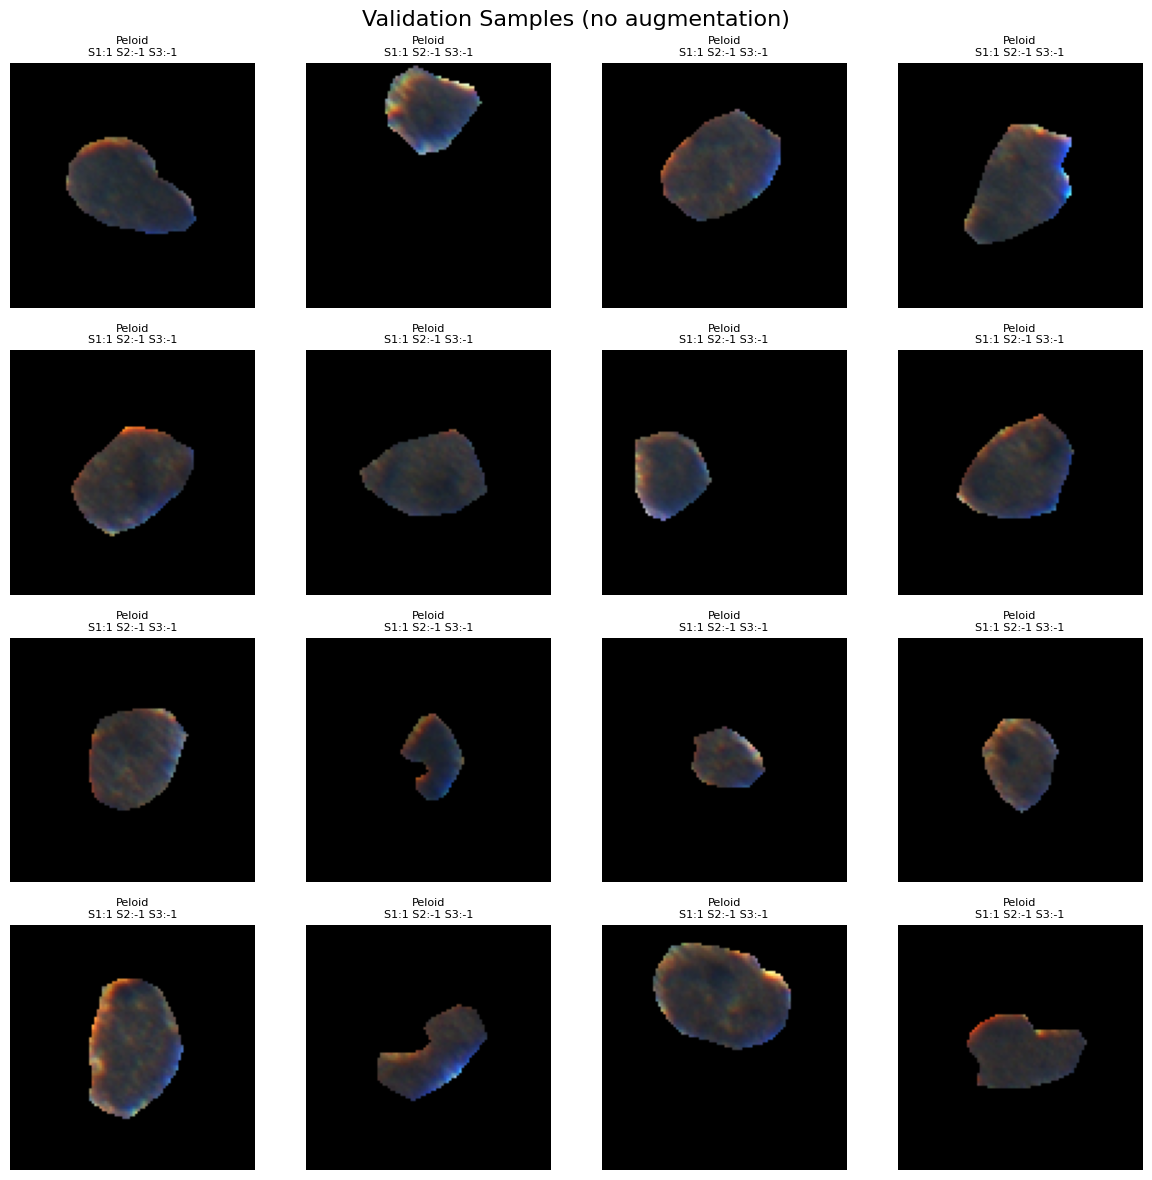

In [5]:
# Visualize validation samples (no augmentation)
visualize_batch(val_loader, "Validation Samples (no augmentation)")

## View Multiple Augmented Versions of Same Image

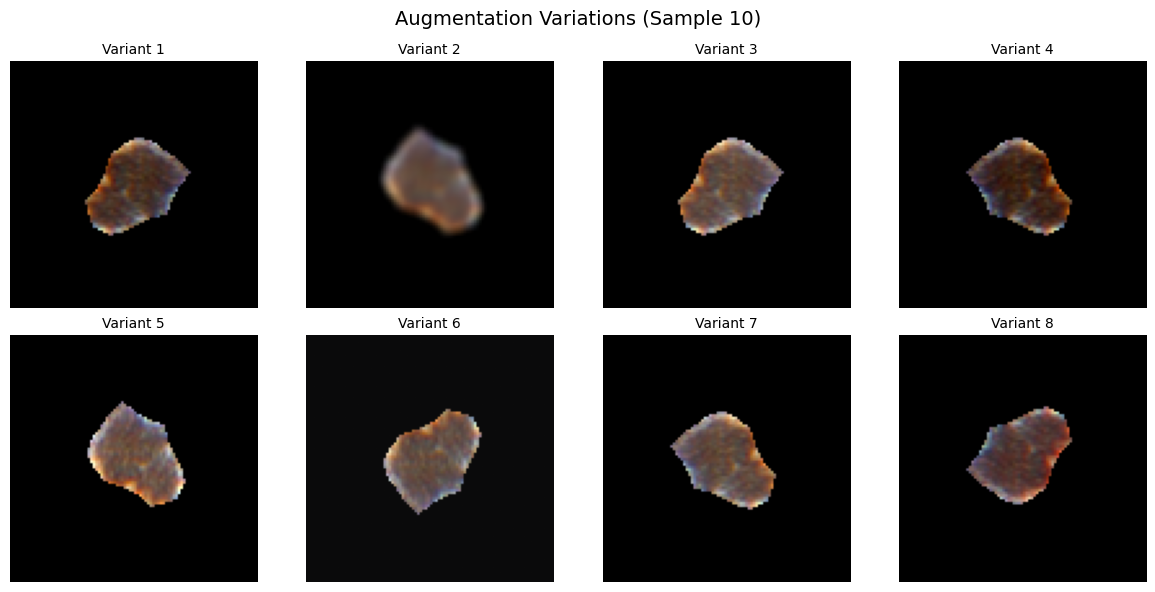

Label: Peloid
Stage 1: 1
Stage 2: -1
Stage 3: -1


In [6]:
# Get the same sample multiple times to see augmentation variations
train_dataset = train_loader.dataset

# Pick a sample index
sample_idx = 10

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle(f"Augmentation Variations (Sample {sample_idx})", fontsize=14)

for i in range(8):
    ax = axes[i // 4, i % 4]
    
    # Get the same sample (augmentation is random each time)
    img, labels, metadata = train_dataset[sample_idx]
    
    # Denormalize
    img = denormalize(img)
    img = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Variant {i+1}", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Label: {metadata['label']}")
print(f"Stage 1: {labels['stage1']}")
print(f"Stage 2: {labels['stage2']}")
print(f"Stage 3: {labels['stage3']}")

## Class Distribution per Stage

In [7]:
def analyze_hierarchical_distribution(loader, split_name):
    """Analyze hierarchical label distribution."""
    all_labels = {'stage1': [], 'stage2': [], 'stage3': []}
    all_classes = []
    
    for images, labels, metadata in loader:
        all_labels['stage1'].extend(labels['stage1'].tolist())
        all_labels['stage2'].extend(labels['stage2'].tolist())
        all_labels['stage3'].extend(labels['stage3'].tolist())
        all_classes.extend(metadata['label'])
    
    print(f"\n{split_name} Set Statistics:")
    print("=" * 60)
    
    # Class distribution
    from collections import Counter
    class_counts = Counter(all_classes)
    print("\nClass Distribution:")
    for cls in ['Peloid', 'Ooid', 'Broken ooid', 'Intraclast']:
        count = class_counts.get(cls, 0)
        pct = 100.0 * count / len(all_classes)
        print(f"  {cls:15s}: {count:4d} ({pct:5.2f}%)")
    
    # Stage 1: Peloid vs Non-peloid
    stage1_arr = np.array(all_labels['stage1'])
    peloid_count = (stage1_arr == 1).sum()
    non_peloid_count = (stage1_arr == 0).sum()
    print(f"\nStage 1 (Peloid vs Non-peloid):")
    print(f"  Peloid:     {peloid_count:4d} ({100*peloid_count/len(stage1_arr):.2f}%)")
    print(f"  Non-peloid: {non_peloid_count:4d} ({100*non_peloid_count/len(stage1_arr):.2f}%)")
    
    # Stage 2: Ooid-like vs Intraclast (only non-peloids)
    stage2_arr = np.array(all_labels['stage2'])
    stage2_valid = stage2_arr[stage2_arr != -1]
    if len(stage2_valid) > 0:
        ooid_like_count = (stage2_valid == 1).sum()
        intraclast_count = (stage2_valid == 0).sum()
        print(f"\nStage 2 (Ooid-like vs Intraclast) [Non-peloids only]:")
        print(f"  Ooid-like:  {ooid_like_count:4d} ({100*ooid_like_count/len(stage2_valid):.2f}%)")
        print(f"  Intraclast: {intraclast_count:4d} ({100*intraclast_count/len(stage2_valid):.2f}%)")
    
    # Stage 3: Whole vs Broken (only ooid-likes)
    stage3_arr = np.array(all_labels['stage3'])
    stage3_valid = stage3_arr[stage3_arr != -1]
    if len(stage3_valid) > 0:
        whole_count = (stage3_valid == 1).sum()
        broken_count = (stage3_valid == 0).sum()
        print(f"\nStage 3 (Whole vs Broken Ooid) [Ooid-likes only]:")
        print(f"  Whole Ooid:  {whole_count:4d} ({100*whole_count/len(stage3_valid):.2f}%)")
        print(f"  Broken Ooid: {broken_count:4d} ({100*broken_count/len(stage3_valid):.2f}%)")

# Analyze both splits
analyze_hierarchical_distribution(train_loader, "Training")
analyze_hierarchical_distribution(val_loader, "Validation")


Training Set Statistics:

Class Distribution:
  Peloid         : 1679 (88.04%)
  Ooid           :  121 ( 6.35%)
  Broken ooid    :   21 ( 1.10%)
  Intraclast     :   86 ( 4.51%)

Stage 1 (Peloid vs Non-peloid):
  Peloid:     1679 (88.04%)
  Non-peloid:  228 (11.96%)

Stage 2 (Ooid-like vs Intraclast) [Non-peloids only]:
  Ooid-like:   142 (62.28%)
  Intraclast:   86 (37.72%)

Stage 3 (Whole vs Broken Ooid) [Ooid-likes only]:
  Whole Ooid:   121 (85.21%)
  Broken Ooid:   21 (14.79%)

Validation Set Statistics:

Class Distribution:
  Peloid         :  621 (84.49%)
  Ooid           :   89 (12.11%)
  Broken ooid    :    8 ( 1.09%)
  Intraclast     :   17 ( 2.31%)

Stage 1 (Peloid vs Non-peloid):
  Peloid:      621 (84.49%)
  Non-peloid:  114 (15.51%)

Stage 2 (Ooid-like vs Intraclast) [Non-peloids only]:
  Ooid-like:    97 (85.09%)
  Intraclast:   17 (14.91%)

Stage 3 (Whole vs Broken Ooid) [Ooid-likes only]:
  Whole Ooid:    89 (91.75%)
  Broken Ooid:    8 (8.25%)


## Check for Data Leakage

Verify that train and validation sets don't share the same images.

In [8]:
def check_data_leakage(train_loader, val_loader):
    """Check if there are any shared images between train and val sets."""
    # Collect image names from each split
    train_images = set()
    val_images = set()
    
    for _, _, metadata in train_loader:
        train_images.update(metadata['image_name'])
    
    for _, _, metadata in val_loader:
        val_images.update(metadata['image_name'])
    
    # Check for overlap
    overlap = train_images.intersection(val_images)
    
    print(f"Training set images: {len(train_images)}")
    print(f"Validation set images: {len(val_images)}")
    print(f"Overlapping images: {len(overlap)}")
    
    if overlap:
        print(f"\n⚠️  DATA LEAKAGE DETECTED!")
        print(f"Shared images: {overlap}")
        return False
    else:
        print(f"\n✅ No data leakage - train and val sets have different images")
        return True

# Check for leakage
check_data_leakage(train_loader, val_loader)

Training set images: 14
Validation set images: 4
Overlapping images: 0

✅ No data leakage - train and val sets have different images


True

## Investigate Colorful Noise Artifacts

The colorful jitter in some training samples might be from aggressive augmentation. Let's check the raw patches before augmentation.

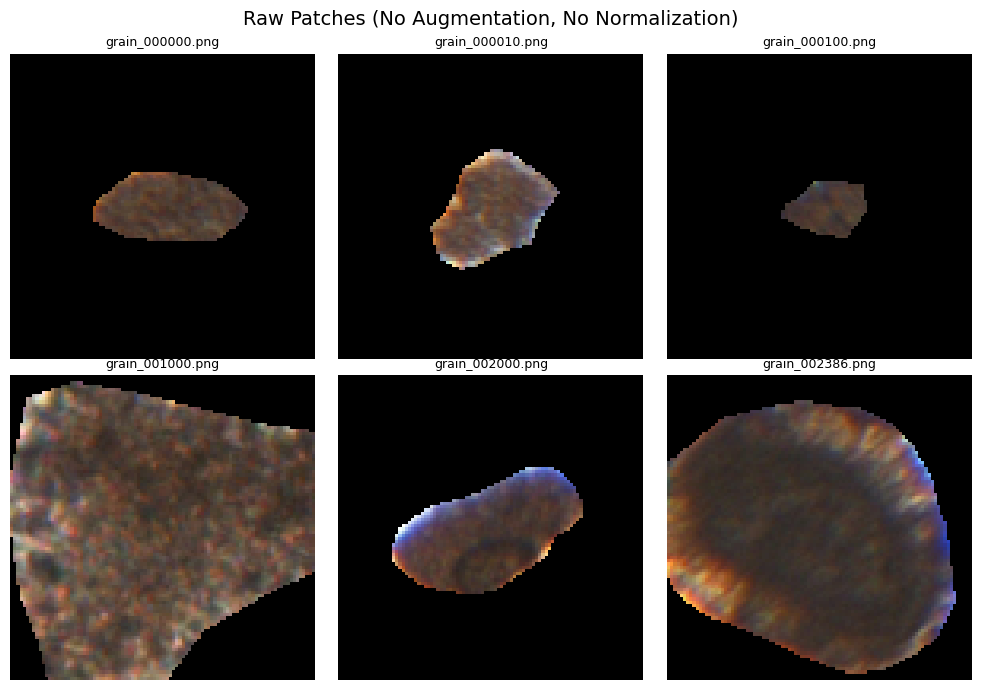


✅ Raw patches look clean - the colorful noise is from augmentation
   Specifically, GaussNoise can create extreme pixel values that
   appear as colorful artifacts when denormalized.


In [9]:
import cv2
from pathlib import Path

# Load a few raw patches without augmentation
patch_dir = Path('../data/processed/patches')
sample_patches = ['grain_000000.png', 'grain_000010.png', 'grain_000100.png', 
                  'grain_001000.png', 'grain_002000.png', 'grain_002386.png']

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle("Raw Patches (No Augmentation, No Normalization)", fontsize=14)

for idx, patch_name in enumerate(sample_patches):
    ax = axes[idx // 3, idx % 3]
    
    # Load raw image
    img_path = patch_dir / patch_name
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(patch_name, fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Raw patches look clean - the colorful noise is from augmentation")
print("   Specifically, GaussNoise can create extreme pixel values that")
print("   appear as colorful artifacts when denormalized.")

## Improved Augmentation (Without Aggressive Noise)

Reload the dataset with the improved augmentation pipeline (removed GaussNoise, reduced color jitter).

Loaded 1907 samples for train split
  Class distribution:
    Peloid         : 1679 (88.04%)
    Ooid           :  121 ( 6.35%)
    Broken ooid    :   21 ( 1.10%)
    Intraclast     :   86 ( 4.51%)
Loaded 735 samples for val split
  Class distribution:
    Peloid         :  621 (84.49%)
    Ooid           :   89 (12.11%)
    Broken ooid    :    8 ( 1.09%)
    Intraclast     :   17 ( 2.31%)


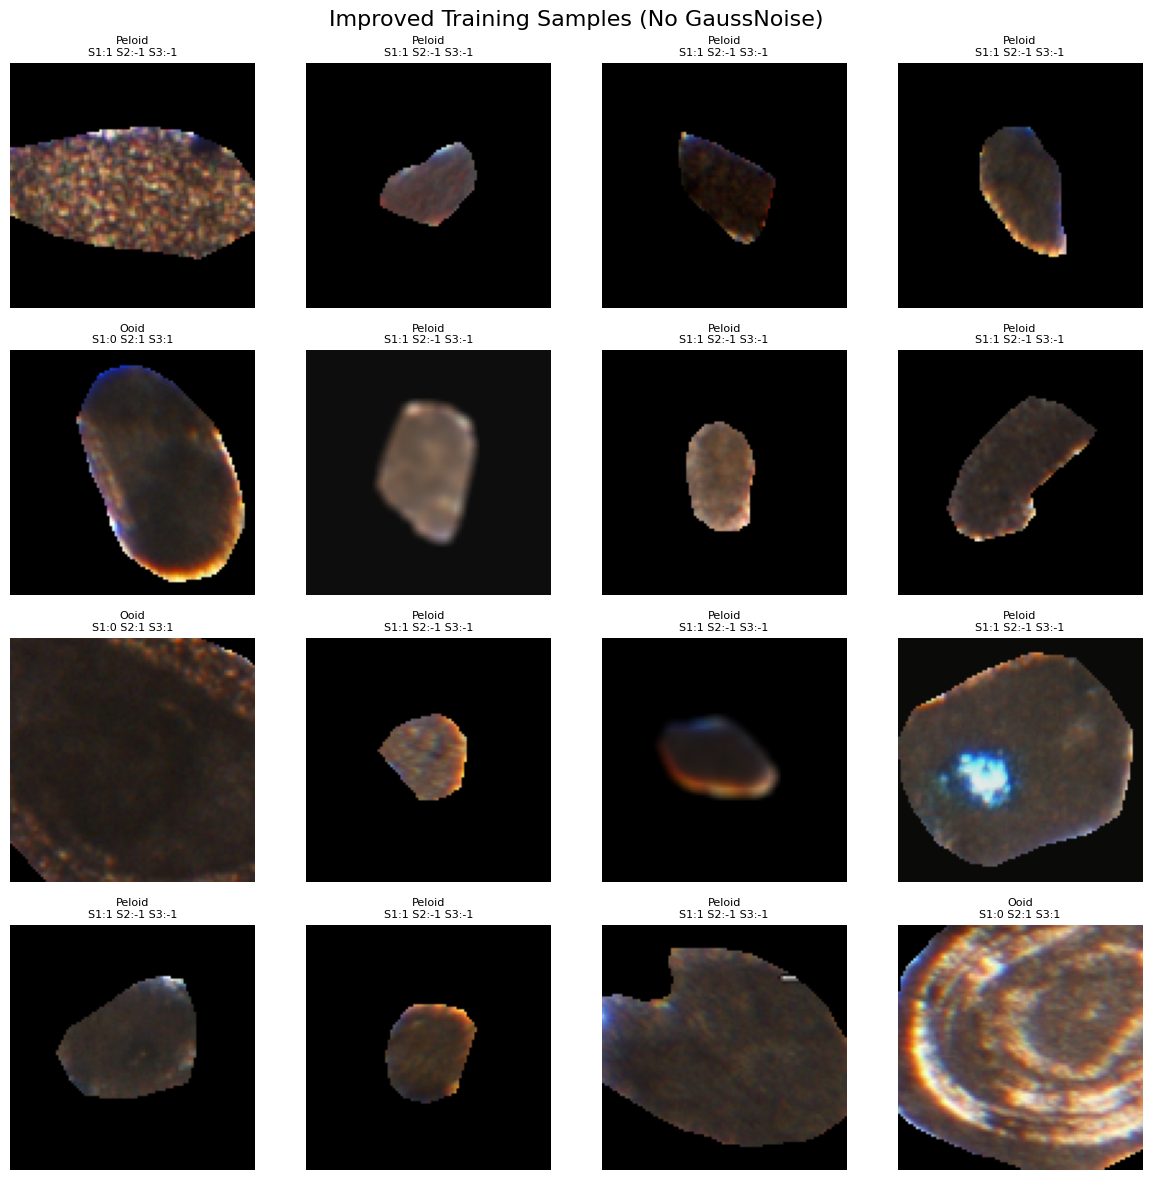


✅ Augmentation improvements:
   - Removed GaussNoise (was causing colorful artifacts)
   - Reduced brightness/contrast limits: 0.2 → 0.15
   - Reduced HSV jitter limits: 10/20/20 → 8/15/15
   - Reduced color jitter probability: 50% → 40%
   - Kept: RandomRotate90, HorizontalFlip, VerticalFlip, GaussianBlur


In [10]:
# Reload the module to get updated augmentation
import importlib
import sys
if 'src.data.dataset' in sys.modules:
    importlib.reload(sys.modules['src.data.dataset'])

from src.data.dataset import create_dataloaders

# Recreate loaders with improved augmentation
train_loader_v2, val_loader_v2 = create_dataloaders(
    fold=0,
    data_dir='../data/processed',
    batch_size=16,
    num_workers=0
)

# Visualize improved training samples
visualize_batch(train_loader_v2, "Improved Training Samples (No GaussNoise)")

print("\n✅ Augmentation improvements:")
print("   - Removed GaussNoise (was causing colorful artifacts)")
print("   - Reduced brightness/contrast limits: 0.2 → 0.15")
print("   - Reduced HSV jitter limits: 10/20/20 → 8/15/15")
print("   - Reduced color jitter probability: 50% → 40%")
print("   - Kept: RandomRotate90, HorizontalFlip, VerticalFlip, GaussianBlur")

## Summary: Data Quality & Leakage Check

**Data Leakage:** ✅ **NONE DETECTED**
- Train and validation sets use completely different images
- Splits are done at the **image level**, not grain level
- This prevents information leakage between folds

**Colorful Artifacts:**
- Some grains naturally show interference colors (optical property of carbonate minerals)
- The extreme rainbow patterns were from **GaussNoise augmentation** (now removed)
- Remaining color variations are from:
  1. Natural optical interference in the original microscopy images
  2. Mild RandomBrightnessContrast and HueSaturationValue augmentations (reduced)
  3. GaussianBlur (20% probability)

**Current Augmentation Pipeline:**
- ✅ RandomRotate90 (100%) - handles any orientation
- ✅ HorizontalFlip (50%) + VerticalFlip (50%)
- ✅ RandomBrightnessContrast OR HueSaturationValue (40%) - mild
- ✅ GaussianBlur (20%) - simulates slight focus variation
- ✅ ImageNet normalization

This is a **conservative augmentation strategy** suitable for microscopy images.